In [1]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt 
%matplotlib inline 

In [3]:
img = cv2.imread('./test_images/messi.jpg') 
img.shape 

# this is give us three dimensions
# 1st two are the x and y and last one is the RGB channel

(820, 1200, 3)

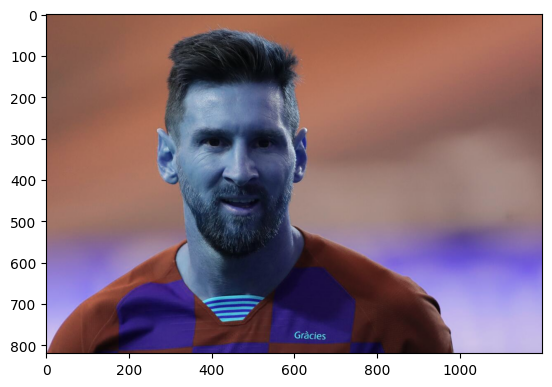

In [4]:
plt.imshow(img) 

In [5]:
# to change the image to gray 
# this will remove the 3rd dimension which is RGB channel 
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) 
gray.shape 

(820, 1200)

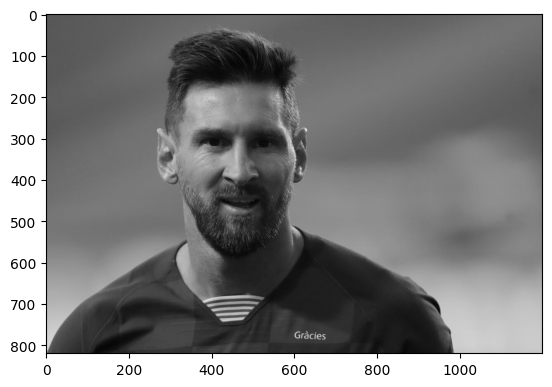

In [7]:
plt.imshow(gray, cmap='gray')  

### Hard Cascade 

In [8]:
face_cascade = cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_frontalface_default.xml') 
eye_cascade = cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_eye.xml') 

faces = face_cascade.detectMultiScale(gray, 1.3, 5)
faces   

array([[293, 176, 350, 350]], dtype=int32)

In [9]:
(x,y,w,h) = faces[0] 
x,y,w,h 

(np.int32(293), np.int32(176), np.int32(350), np.int32(350))

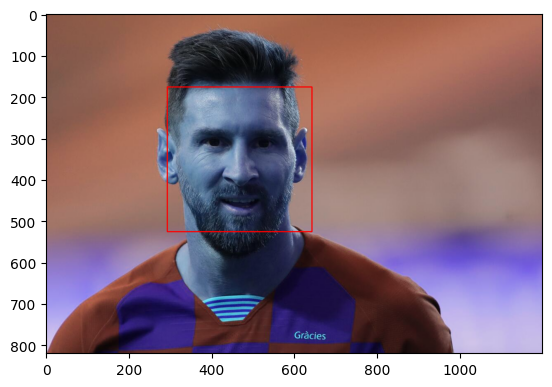

In [12]:
face_img = cv2.rectangle(img, (x,y), (x+w, y+h), (255,0,0), 2) 
plt.imshow(face_img) 

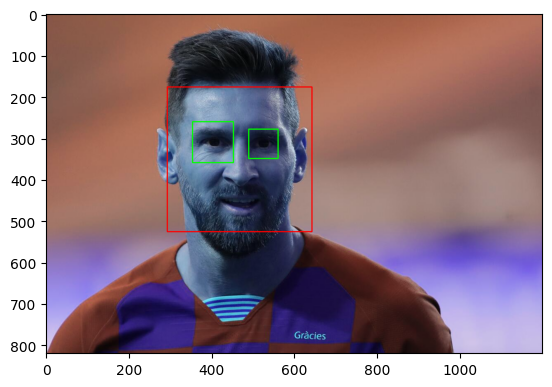

In [ ]:
cv2.destroyAllWindows() 
for (x,y,w,h) in faces: 
    face_img = cv2.rectangle(img, (x,y), (x+w, y+h), (255,0,0), 2) 
    roi_gray = gray[y:y+h, x:x+w] 
    roi_color = face_img[y:y+h, x:x+w]  # the red rectangle
    eyes = eye_cascade.detectMultiScale(roi_gray) 
    for (ex, ey, ew, eh) in eyes: 
        cv2.rectangle(roi_color, (ex,ey), (ex+ew, ey+eh), (0,255,0), 2)
        
plt.figure() 
plt.imshow(face_img, cmap='gray') 
plt.show() 


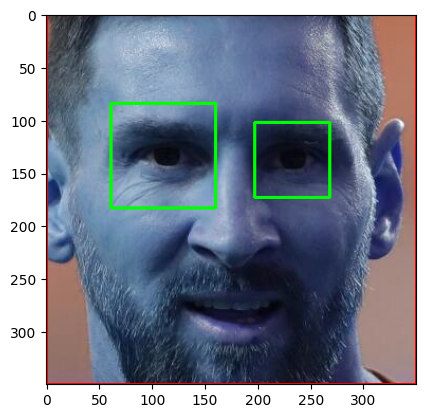

In [14]:
plt.imshow(roi_color, cmap='gray') 

In [20]:
def get_cropped_image_if_2_eyes(image_path): 
    img = cv2.imread(image_path) 
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5) 
    for (x,y,w,h) in faces: 
        roi_gray = gray[y:y+h, x:x+w] 
        roi_color = img[y:y+h, x:x+w] 
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2: 
            return roi_color 
        else: 
            return None

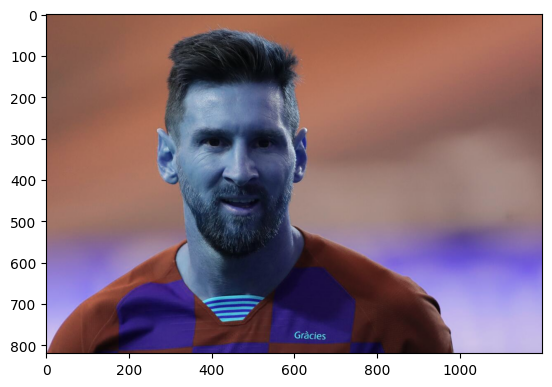

In [21]:
original_img = cv2.imread('./test_images/messi.jpg') 
plt.imshow(original_img) 

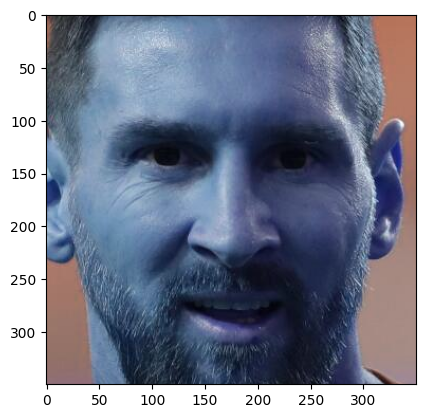

In [22]:
cropped_img = get_cropped_image_if_2_eyes('./test_images/messi.jpg')
plt.imshow(cropped_img) 

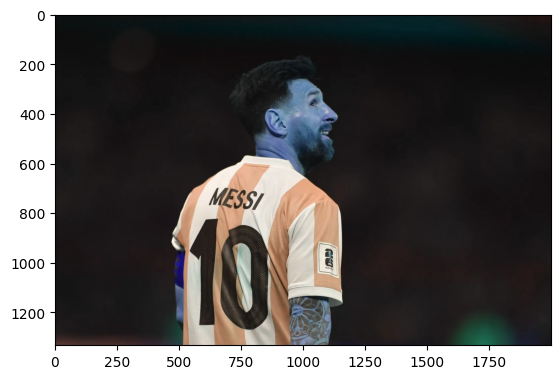

In [23]:
original_img = cv2.imread('./test_images/messi2.jpg')
plt.imshow(original_img) 

### Data Cleaning

In [25]:
cropped_img_no_2_eyes = get_cropped_image_if_2_eyes('./test_images/messi2.jpg') 
cropped_img_no_2_eyes

In [26]:
path_to_data = './dataset/'
path_to_cr_data = './dataset/cropped/'  

In [27]:
import os 
img_dirs = [] 
for entry in os.scandir(path_to_data): 
    if entry.is_dir(): 
        img_dirs.append(entry.path)

In [28]:
img_dirs 

['./dataset/aitana_bonmati',
 './dataset/angel_d_maria',
 './dataset/lewandowski',
 './dataset/lionel_messi',
 './dataset/pedri']

In [30]:
# creating the cropped folder 
import shutil
if os.path.exists(path_to_cr_data): 
    # to remove the folder if the folders is already exists
    shutil.rmtree(path_to_cr_data) 
os.mkdir(path_to_cr_data) 

In [33]:
cropped_img_dirs = [] 
person_file_names_dict = {} 

for img_dir in img_dirs: 
    count = 1
    person_name =  img_dir.split('/')[-1]   # gives the last element of the list which is the person name 
    
    person_file_names_dict[person_name] = []
    
    for entry in os.scandir(img_dir): 
        try:
            # Ensure the file is an image before processing
            if entry.name.lower().endswith(('.png', '.jpg', '.jpeg')):
                roi_color = get_cropped_image_if_2_eyes(entry.path)
                if roi_color is not None: 
                    cropped_folder = path_to_cr_data + person_name 
                    if not os.path.exists(cropped_folder): 
                        os.makedirs(cropped_folder)   # to create the folder
                        cropped_img_dirs.append(cropped_folder)
                        print(f'Generating cropped images in folder: {cropped_folder}')
                
                    cropped_file_name = person_name + str(count) + '.png'
                    cropped_file_path = cropped_folder + '/' + cropped_file_name
                    
                    cv2.imwrite(cropped_file_path, roi_color)
                    person_file_names_dict[person_name].append(cropped_file_path)
                    count += 1
        except Exception as e:
            print(f"Error processing file {entry.path}: {e}")
                
    

Generating cropped images in folder: ./dataset/cropped/angel_d_maria
Generating cropped images in folder: ./dataset/cropped/lewandowski
Generating cropped images in folder: ./dataset/cropped/lionel_messi
Generating cropped images in folder: ./dataset/cropped/pedri


### Feature Engineering

In [38]:
# wavelet transformation allows us to extract importance parts of our image
import pywt 

def w2d(img, mode='harr', level=1):
    imArray = img 
    # Datatype conversions 
    # convert to grayscale 
    imArray = cv2.cvtColor(imArray, cv2.COLOR_RGB2GRAY) 
    # convert to float 
    imArray = np.float32(imArray) 
    imArray /= 255 
    # compute coefficients 
    coeffs = pywt.wavedec2(imArray, mode, level=level) 
    
    # process coefficents 
    coeffs_H = list(coeffs) 
    coeffs_H[0] *= 0 
    
    # reconstruction 
    imArray_H = pywt.waverec2(coeffs_H, mode) 
    imArray_H *= 255 
    imArray_H = np.uint8(imArray_H) 
    
    return imArray_H 
    

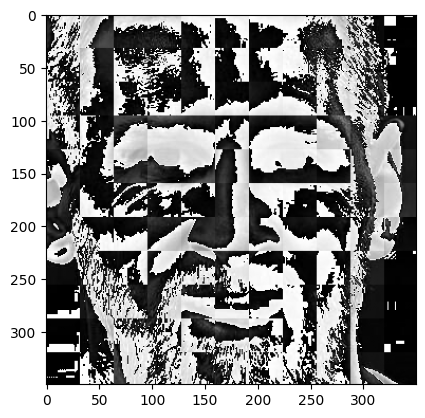

In [39]:
im_har = w2d(cropped_img, 'db1', 5) 
plt.imshow(im_har, cmap='gray') 

In [40]:
person_file_names_dict 

{'aitana_bonmati': ['./dataset/cropped/aitana_bonmati/aitana_bonmati1.png',
  './dataset/cropped/aitana_bonmati/aitana_bonmati2.png',
  './dataset/cropped/aitana_bonmati/aitana_bonmati3.png',
  './dataset/cropped/aitana_bonmati/aitana_bonmati4.png',
  './dataset/cropped/aitana_bonmati/aitana_bonmati5.png',
  './dataset/cropped/aitana_bonmati/aitana_bonmati6.png',
  './dataset/cropped/aitana_bonmati/aitana_bonmati7.png',
  './dataset/cropped/aitana_bonmati/aitana_bonmati8.png',
  './dataset/cropped/aitana_bonmati/aitana_bonmati9.png',
  './dataset/cropped/aitana_bonmati/aitana_bonmati10.png',
  './dataset/cropped/aitana_bonmati/aitana_bonmati11.png',
  './dataset/cropped/aitana_bonmati/aitana_bonmati12.png',
  './dataset/cropped/aitana_bonmati/aitana_bonmati13.png',
  './dataset/cropped/aitana_bonmati/aitana_bonmati14.png',
  './dataset/cropped/aitana_bonmati/aitana_bonmati15.png',
  './dataset/cropped/aitana_bonmati/aitana_bonmati16.png',
  './dataset/cropped/aitana_bonmati/aitana_bonm

In [41]:
# vertically stacking images 

In [42]:
class_dict = {} 
count = 0 
for person_name in person_file_names_dict.keys(): 
    class_dict[person_name] = count  
    count = count + 1 

class_dict 

{'aitana_bonmati': 0,
 'angel_d_maria': 1,
 'lewandowski': 2,
 'lionel_messi': 3,
 'pedri': 4}

In [43]:
X = []
y = []

for person_name, training_files in person_file_names_dict.items(): 
    for training_img in training_files: 
       img = cv2.imread(training_img)
       
       if img is None:
           continue
       
       scalled_raw_img = cv2.resize(img, (32,32))  # we should have images with the same size to train, so we should scale the raw image 
       img_har = w2d(img, 'db1', 5)
       scalled_image_har = cv2.resize(img_har, (32,32)) 
       # to vertical stack images 
       # scalled raw img has 32, 32, 3 into matrix because it is a colorful image, 3 is about rgb
       combined_img = np.vstack((scalled_raw_img.reshape(32*32*3, 1), scalled_image_har.reshape(32*32,1)))
       X.append(combined_img) 
       y.append(class_dict[person_name])

In [44]:
len(X) 

866

In [46]:
32*32*3 + 32*32

4096

In [ ]:
len(X[0])

4096

In [47]:
X[0] 

array([[ 25],
       [ 20],
       [ 21],
       ...,
       [  1],
       [250],
       [247]], dtype=uint8)

In [48]:
X = np.array(X).reshape(len(X), 4096).astype(float)
X.shape 

(866, 4096)

In [49]:
X[0] 

array([ 25.,  20.,  21., ...,   1., 250., 247.])

In [50]:
len(y) 

866

In [52]:
y

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


### **Training the model**

#### let's try SVM with rbf kernel tuned with heuristic finetuning 


In [53]:
from sklearn.svm import SVC 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split 
from sklearn.pipeline import Pipeline 
from sklearn.metrics import classification_report 

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0) 

# use this to scale the images 
pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='rbf', C=10))])
pipe.fit(X_train, y_train) 

Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC(C=10))])

In [55]:
pipe.score(X_test, y_test) 

0.8617511520737328

In [56]:
len(X_test) 

217

In [57]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.80      0.90      0.84        39
           1       0.85      0.81      0.83        43
           2       0.86      0.94      0.90        70
           3       0.96      0.75      0.84        36
           4       0.89      0.83      0.86        29

    accuracy                           0.86       217
   macro avg       0.87      0.85      0.86       217
weighted avg       0.87      0.86      0.86       217



In [58]:
# hypertuning 
# use gridsearchcv to find the best model 
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

model_params = {
    'svm': {
        'model': SVC(gamma='auto', probability=True), 
        'params': {
            'svc__C': [1,10,100,1000], 
            'svc__kernel': ['rbf', 'linear']
        }
    }, 
    'random_forest': {
        'model': RandomForestClassifier(), 
        'params': {
            'randomforestclassifier__n_estimators': [1,5,10], 
        }
    }, 
    'logistic_regression': {
        'model': LogisticRegression(solver='liblinear', multi_class='auto'), 
        'params': {
            'logisticregression__C': [1,5,10]
        }
    }
}
    

In [61]:
scores = []
best_estimators = {}
import pandas as pd 
from sklearn.pipeline import make_pipeline

for model_name, model in model_params.items(): 
    pipe = make_pipeline(StandardScaler() , model['model'])
    clf = GridSearchCV(pipe, model['params'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': model_name, 
        'best_score': clf.best_score_,  
        'best_params': clf.best_params_ 
    })
    best_estimators[model_name] = clf.best_estimator_ 
    
df = pd.DataFrame(scores)
df 

C:\Users\madhu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\madhu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\madhu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in versio

,model,best_score,best_params
0,svm,0.864496,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.665629,{'randomforestclassifier__n_estimators': 10}
2,logistic_regression,0.881419,{'logisticregression__C': 1}


In [62]:
best_estimators

{'svm': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('svc',
                  SVC(C=1, gamma='auto', kernel='linear', probability=True))]),
 'random_forest': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('randomforestclassifier',
                  RandomForestClassifier(n_estimators=10))]),
 'logistic_regression': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression',
                  LogisticRegression(C=1, multi_class='auto',
                                     solver='liblinear'))])}

In [63]:
best_estimators['svm'].score(X_test, y_test) 

0.8894009216589862

In [64]:
best_estimators['random_forest'].score(X_test, y_test) 

0.6774193548387096

In [65]:
best_estimators['logistic_regression'].score(X_test, y_test) 

0.9124423963133641

In [66]:
best_clf = best_estimators['logistic_regression'] 

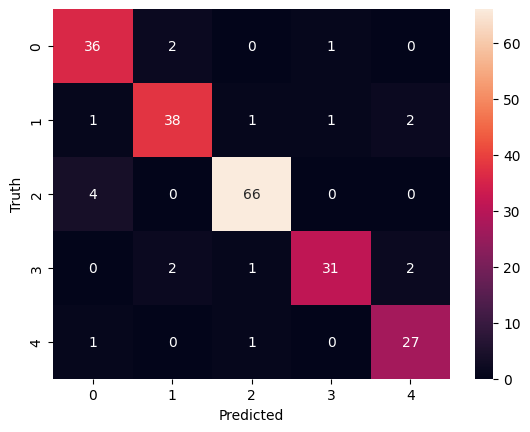

In [70]:
# Confussion Matrix
from sklearn.metrics import confusion_matrix 
import seaborn as sn   

plt.figure() 
cm = confusion_matrix(y_test, best_clf.predict(X_test)) 
sn.heatmap(cm, annot=True) 
plt.xlabel('Predicted')
plt.ylabel('Truth') 
plt.show() 

In [69]:
class_dict 

{'aitana_bonmati': 0,
 'angel_d_maria': 1,
 'lewandowski': 2,
 'lionel_messi': 3,
 'pedri': 4}

In [71]:
# save the trained model 
import joblib 

joblib.dump(best_clf, 'model.pkl') 

['model.pkl']

In [72]:
# save the class dictinoary 
import json 
with open('class_dictionary.json', 'w') as f: 
    f.write(json.dumps(class_dict)) 